# Importing Libraries & Loading the Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

We load the MNIST dataset, which contains thousands of 28×28 grayscale images of handwritten digits (0–9). These images will help our CNN learn how digits look.

# Conv3x3 Layer

This defines a convolution layer that:

* Uses multiple 3×3 filters.

* Slides these filters across the image.

* Produces feature maps.

* Updates filters using backpropagation.

In [ ]:
class Conv3x3:
    def __init__(self, num_filters):
        self.num_filters = num_filters
        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def iterate_regions(self, image):
        h, w = image.shape
        for i in range(h - 2):
            for j in range(w - 2):
                im_region = image[i:(i + 3), j:(j + 3)]
                yield im_region, i, j

    def forward(self, input):
        self.last_input = input
        h, w = input.shape
        output = np.zeros((h - 2, w - 2, self.num_filters))
        for im_region, i, j in self.iterate_regions(input):
            output[i, j] = np.sum(im_region * self.filters, axis=(1, 2))
        return output

    def backprop(self, d_L_d_out, learn_rate):
        d_L_d_filters = np.zeros(self.filters.shape)
        for im_region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                d_L_d_filters[f] += d_L_d_out[i, j, f] * im_region
        self.filters -= learn_rate * d_L_d_filters
        return None

This layer is where the model starts “looking” at the image.

Each 3×3 filter acts like a tiny pattern detector. When it slides over the image:

* If the small region matches the filter pattern,

* The output value becomes high.

For example:

* Some filters may detect edges.

* Some may detect curves.

* Some may detect diagonal strokes.

Instead of memorizing full digits, the CNN first learns basic building blocks of digits.

During backpropagation:

* If the prediction is wrong,

* The filters slightly adjust themselves,

* So next time they detect features more accurately.

This layer helps the network understand what parts of the image are important.

# MaxPool2 Layer

This layer:

* Takes 2×2 regions.

* Picks the maximum value.

* Reduces image size by half.

* Passes gradients correctly during backpropagation.

In [ ]:
class MaxPool2:
    def iterate_regions(self, image):
        h, w, _ = image.shape
        for i in range(h // 2):
            for j in range(w // 2):
                im_region = image[(i * 2):(i * 2 + 2), (j * 2):(j * 2 + 2)]
                yield im_region, i, j

    def forward(self, input):
        self.last_input = input
        h, w, num_filters = input.shape
        output = np.zeros((h // 2, w // 2, num_filters))
        for im_region, i, j in self.iterate_regions(input):
            output[i, j] = np.amax(im_region, axis=(0, 1))
        return output

    def backprop(self, d_L_d_out):
        d_L_d_input = np.zeros(self.last_input.shape)
        for im_region, i, j in self.iterate_regions(self.last_input):
            h, w, f = im_region.shape
            amax = np.amax(im_region, axis=(0, 1))
            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):
                        if im_region[i2, j2, f2] == amax[f2]:
                            d_L_d_input[i * 2 + i2, j * 2 + j2, f2] = d_L_d_out[i, j, f2]
        return d_L_d_input

After convolution, we get many feature maps.
But they are still large.

MaxPooling reduces the size while keeping important information.

Imagine you are summarizing notes:

* Instead of keeping every word,

* You keep only the most important points.

That is exactly what max pooling does:

* It keeps the strongest activation.

* It throws away weaker signals.

This also makes the model more stable.
If the digit shifts slightly left or right, the strongest feature will still be captured.

So this layer:

* Reduces computation,

* Prevents overfitting,

* Makes the model translation-invariant.

# Softmax Layer - Fully Connected Layer

This layer:

* Flattens the 3D output into a 1D vector.

* Multiplies by weights.

* Adds biases.

* Converts scores into probabilities using Softmax.

* Performs backpropagation to update weights.

In [ ]:
class Softmax:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)

    def forward(self, input):
        self.last_input_shape = input.shape
        input = input.flatten()
        self.last_input = input
        totals = np.dot(input, self.weights) + self.biases
        self.last_totals = totals
        exp = np.exp(totals - np.max(totals))
        return exp / np.sum(exp, axis=0)

    def backprop(self, d_L_d_out, learn_rate):
        for i, gradient in enumerate(d_L_d_out):
            if gradient == 0: continue
            t_exp = np.exp(self.last_totals)
            S = np.sum(t_exp)
            d_out_d_t = -t_exp[i] * t_exp / (S**2)
            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S**2)
            d_L_d_t = gradient * d_out_d_t
            d_L_d_w = self.last_input[None].T @ d_L_d_t[None]
            d_L_d_inputs = self.weights @ d_L_d_t
            self.weights -= learn_rate * d_L_d_w
            self.biases -= learn_rate * d_L_d_t
            return d_L_d_inputs.reshape(self.last_input_shape)

This is the final decision-making part.

Up until now:

* The network extracted features.

* Reduced them.

* Highlighted important patterns.

Now we convert everything into a decision.

The flatten step:
We take all feature maps and stretch them into one long list of numbers.

Then:

* Each number gets multiplied by weights.

* These weights represent how important each feature is.

Finally, Softmax converts raw numbers into probabilities.

Example:

* 90% chance digit is 3

* 5% chance digit is 8

* 5% chance digit is 5

The model chooses the highest probability as its prediction.

This is like a final voting system.

# Data Preparation

This step:

* Loads training and test data.

* Normalizes pixel values.

* Uses only 500 training images.

* Initializes Conv, Pool, and Softmax layers.

In [ ]:
# --- DATA PREP (500 IMAGES ONLY) ---
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images[:500] / 255 - 0.5  # <--- LIMIT TO 500
train_labels = train_labels[:500]
test_images = test_images[:100] / 255 - 0.5

# Initialize Network
conv = Conv3x3(8)
pool = MaxPool2()
softmax = Softmax(13 * 13 * 8, 10)

Here we prepare the data properly.

Why normalize?
Original pixel values range from 0 to 255.
Large values can slow down learning.
So we scale them between -0.5 and 0.5.

Why limit to 500 images?
Because:

* We are implementing CNN from scratch.

* It is computationally heavy.

* This is just for demonstration and learning.

Then we build our network:
Conv → Pool → Softmax

This defines the complete architecture.

In [ ]:
def forward(image, label):
    out = conv.forward(image)
    out = pool.forward(out)
    out = softmax.forward(out)
    loss = -np.log(out[label])
    acc = 1 if np.argmax(out) == label else 0
    return out, loss, acc

Passes one image through:
Conv → Pool → Softmax

Calculates:

* Loss (how wrong prediction is)

* Accuracy (correct or not)

This function shows how one image travels through the network.

Steps:

1. Extract features.

2. Reduce features.

3. Predict digit.

4. Compare prediction with actual label.

5. Calculate error using negative log likelihood.

If the model predicts wrong with high confidence,
loss becomes large.

If it predicts correctly with high confidence,
loss becomes very small.

This function evaluates performance for one image.

In [ ]:
def train(im, label, lr=0.005):
    out, loss, acc = forward(im, label)
    gradient = np.zeros(10)
    gradient[label] = -1 / out[label]
    gradient = softmax.backprop(gradient, lr)
    gradient = pool.backprop(gradient)
    conv.backprop(gradient, lr)
    return loss, acc

* Computes gradient of loss.

* Sends error backward.

* Updates weights in Softmax and Conv layers.

This is where real learning happens.

If prediction is wrong:

* We measure how wrong it was.

* We calculate gradients (direction to improve).

* We adjust weights slightly.

Each update is small.
But after many images,
these small updates accumulate,
and the model becomes smarter.

This is gradient descent in action.

# Training Loop

* Runs training for 5 epochs.
* Tracks average loss and accuracy.
* Prints results after each epoch.



In [ ]:
print("Starting Training on 500 images...")
losses = []
accuracies = []

for epoch in range(5): # More epochs since data is small
    l_total, a_total = 0, 0
    for im, label in zip(train_images, train_labels):
        l, a = train(im, label)
        l_total += l
        a_total += a

    avg_loss = l_total / len(train_images)
    avg_acc = a_total / len(train_images)
    losses.append(avg_loss)
    accuracies.append(avg_acc)
    print(f'Epoch {epoch + 1}: Loss {avg_loss:.3f} | Accuracy: {avg_acc:.2f}')

Starting Training on 500 images...
Epoch 1: Loss 1.496 | Accuracy: 0.54
Epoch 2: Loss 0.611 | Accuracy: 0.81
Epoch 3: Loss 0.449 | Accuracy: 0.86
Epoch 4: Loss 0.365 | Accuracy: 0.89
Epoch 5: Loss 0.306 | Accuracy: 0.91


An epoch means:
The model has seen all 500 images once.

With each epoch:

* The filters become better.

* The classifier becomes more confident.

* Loss decreases.

* Accuracy increases.

Example trend:

* Epoch 1: 54% accuracy

* Epoch 5: 91% accuracy

This shows the model is learning successfully.

# Plotting Graphs

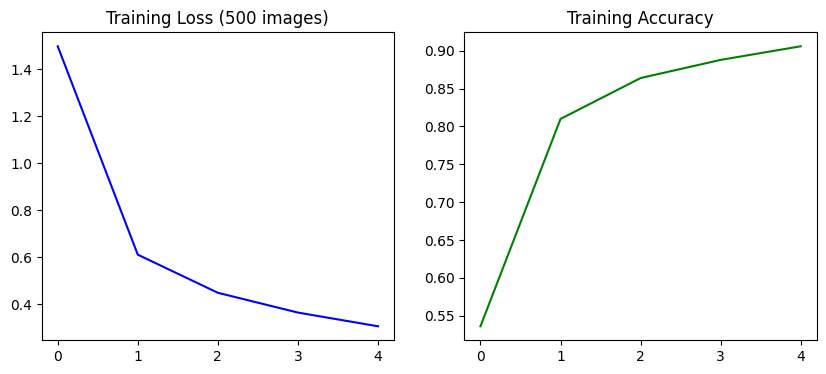

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, color='blue', label='Loss')
plt.title('Training Loss (500 images)')
plt.subplot(1, 2, 2)
plt.plot(accuracies, color='green', label='Accuracy')
plt.title('Training Accuracy')
plt.show()

This gives visual proof of learning.

If:

* Loss curve goes down

* Accuracy curve goes up

Then training is working properly. If curves behave strangely,
there may be an issue.

Visualization helps us monitor learning behavior.

# Testing on One Image

* Takes one unseen test image.

* Predicts digit.

* Displays prediction vs actual.

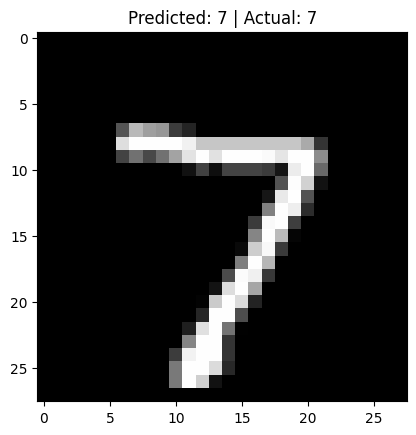

In [ ]:
test_idx = 0
out, _, _ = forward(test_images[test_idx], test_labels[test_idx])
plt.imshow(test_images[test_idx], cmap='gray')
plt.title(f"Predicted: {np.argmax(out)} | Actual: {test_labels[test_idx]}")
plt.show()

This checks generalization.

Training accuracy shows how well the model learned from training data.

Testing checks:
Can it recognize new digits it has never seen before?

If prediction matches actual,
it means the model truly learned patterns,
not just memorized images.